# Hybrid Conv + DenseAM Latent Free-Energy Model on MNIST

This notebook investigates the failure mode of the pure local convolutional latent free-energy model. The pure conv model learns local stroke fragments, but it has no global hidden variable that says "these strokes form a coherent zero or one." The hybrid model keeps the conservative free-energy construction and adds a global categorical DenseAM term:

```math
\log p_\theta(x,t) = \log p_{conv}(x,t) + \lambda \log \sum_a \exp \ell_a(x,t)
```

with

```math
\ell_a(x,t)=\frac{\alpha_t x^T c_a}{\sigma_t^2}-\frac{\alpha_t^2\|c_a\|^2}{2\sigma_t^2}+b_a.
```

The conv hidden units model local strokes; the categorical DenseAM hidden unit models whole-image geometry. The score remains conservative because it is still the gradient of a single scalar free energy.

In [1]:
import math
import time
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]
Default backend: gpu


## Configuration

The sweep is deliberately wider than the pure-conv notebook. It tests whether global prototype memory actually fixes the qualitative failure, not just whether one hyperparameter happens to look better.

In [ ]:
SEED = 0
RESEARCH_MODE = False

IMG_SIDE = 12
DIGITS = (0, 1)

if RESEARCH_MODE:
    N_TRAIN = 4096
    N_VALID = 1024
    N_TIME_SWEEP = 10
    STEPS_PER_TIME_SWEEP = 450
    N_TIME_FINAL = 14
    STEPS_PER_TIME_FINAL = 1800
    BATCH_SIZE = 192
    N_REVERSE_STEPS = 420
    N_SAMPLES = 96
    K_VALUES = [16, 32, 64, 128]
    LAMBDA_VALUES = [0.2, 0.5, 1.0, 1.5]
    INIT_KINDS = ["random", "kmeans"]
else:
    N_TRAIN = 2000
    N_VALID = 512
    N_TIME_SWEEP = 8
    STEPS_PER_TIME_SWEEP = 300
    N_TIME_FINAL = 12
    STEPS_PER_TIME_FINAL = 1200
    BATCH_SIZE = 128
    N_REVERSE_STEPS = 320
    N_SAMPLES = 64
    K_VALUES = [16, 32, 64, 128]
    LAMBDA_VALUES = [0.25, 0.5, 1.0]
    INIT_KINDS = ["random", "kmeans"]

# Conv layer kept fixed at the best small pure-conv operating point.
CONV_HIDDEN_CH = 32
CONV_KERNEL = 5
CONV_W_SCALE = 0.035
HIDDEN_BIAS_SCALE = -1.25
VISIBLE_BIAS_SCALE = 0.0

LR = 1e-3
GRAD_CLIP = 10.0
REG_SCALE = 1e-6
PROTO_REG_SCALE = 2e-6

kBT = 1.0
TAU = 3.0
T_MIN = 8e-2
TIME_GRID_SWEEP = jnp.linspace(T_MIN, TAU, N_TIME_SWEEP)
TIME_GRID_FINAL = jnp.linspace(T_MIN, TAU, N_TIME_FINAL)

key = random.PRNGKey(SEED)
print(f"hybrid sweep: K={K_VALUES}, lambda={LAMBDA_VALUES}, init={INIT_KINDS}")

hybrid sweep: K=[16, 32, 64, 128], lambda=[0.25, 0.5, 1.0], init=['random', 'kmeans']


2026-05-22 22:39:34.727618: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params), "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g), state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps), params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}

## MNIST 0/1 Data

Pixels are downsampled to `12 x 12` and mapped to `[-1, 1]`, matching the pure-conv experiment.

2026-05-22 22:39:34.980852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779489574.991848  152829 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779489574.995343  152829 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


train_images: (2000, 28, 28, 1) float32
valid_images: (512, 28, 28, 1) float32
train mean/std: -0.7363691329956055 0.6185520887374878
train class counts: {0: 201, 1: 211, 2: 184, 3: 196, 4: 182, 5: 197, 6: 214, 7: 216, 8: 199, 9: 200}


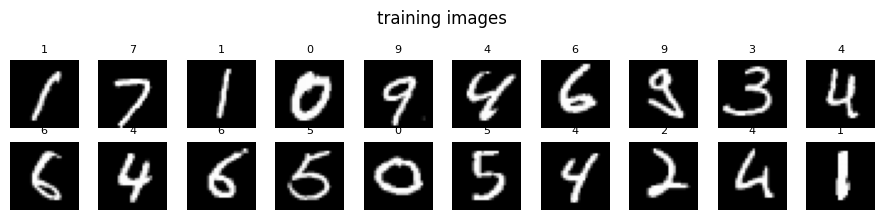

In [4]:
def _load_mnist_raw():
    from tensorflow.keras.datasets import mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    return np.asarray(x_train, dtype=np.uint8), np.asarray(y_train, dtype=np.int32), np.asarray(x_test, dtype=np.uint8), np.asarray(y_test, dtype=np.int32)


def downsample_avg(x_28, out_side):
    k = 28 // out_side
    cropped_side = out_side * k
    pad = (28 - cropped_side) // 2
    x = x_28[:, pad:pad + cropped_side, pad:pad + cropped_side].astype(np.float32) / 255.0
    if k > 1:
        x = x.reshape(-1, out_side, k, out_side, k).mean(axis=(2, 4))
    return x


def prep_mnist_split(x_raw, y_raw, digits, n, out_side, seed):
    mask = np.isin(y_raw, np.asarray(digits))
    x = x_raw[mask]
    y = y_raw[mask]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(x.shape[0])[:n]
    x = downsample_avg(x[idx], out_side)
    x = 2.0 * x - 1.0
    x = x[..., None]
    return jnp.asarray(x), jnp.asarray(y[idx])


x_train_raw, y_train_raw, x_test_raw, y_test_raw = _load_mnist_raw()
train_images, train_labels = prep_mnist_split(x_train_raw, y_train_raw, DIGITS, N_TRAIN, IMG_SIDE, SEED)
valid_images, valid_labels = prep_mnist_split(x_test_raw, y_test_raw, DIGITS, N_VALID, IMG_SIDE, SEED + 1)

print("train_images:", train_images.shape, train_images.dtype)
print("valid_images:", valid_images.shape, valid_images.dtype)
print("train mean/std:", float(jnp.mean(train_images)), float(jnp.std(train_images)))
print("train class counts:", {int(d): int(jnp.sum(train_labels == d)) for d in DIGITS})

fig, axes = plt.subplots(2, 10, figsize=(9.0, 2.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(np.asarray(train_images[i, :, :, 0]), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(int(train_labels[i]), fontsize=8)
    ax.axis("off")
plt.suptitle("training images")
plt.tight_layout()
plt.show()

In [5]:
def ou_coeffs(t, kBT_val=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT_val * (1.0 - a * a)
    return a, jnp.maximum(sigma2, 1e-6)


def corrupt_ou(key, x0, t, kBT_val=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT_val)
    xt = a * x0 + jnp.sqrt(sigma2) * eps
    target = -kBT_val * (xt - a * x0) / sigma2
    return xt, target

## Hybrid Free-Energy Model

The score decomposes into the local conv score plus a global prototype pull:

```math
s(x,t)=s_{conv}(x,t)+\lambda \frac{\alpha_t}{\sigma_t^2}\sum_a r_a(x,t)c_a.
```

`r_a` is the DenseAM posterior over prototypes. This term provides global digit coherence.

In [6]:
def conv_encoder(x, W):
    return lax.conv_general_dilated(x, W, window_strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"))


def conv_transpose_tied(q, W):
    return lax.conv_transpose(q, W, strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"), transpose_kernel=True)


def conv_hidden(conv, x):
    z = conv_encoder(x, conv["W"]) + conv["a"][None, None, None, :]
    q = jax.nn.sigmoid(z)
    return z, q


def conv_score(conv, x, sigma2):
    _, q = conv_hidden(conv, x)
    return -x / sigma2 + conv["b"] + conv_transpose_tied(q, conv["W"])


def conv_log_unnormalized(conv, x, sigma2):
    z, _ = conv_hidden(conv, x)
    quad = -0.5 * jnp.sum(x * x, axis=(1, 2, 3)) / sigma2
    visible = jnp.sum(conv["b"] * x, axis=(1, 2, 3))
    hidden = jnp.sum(jax.nn.softplus(z), axis=(1, 2, 3))
    return quad + visible + hidden


def denseam_logits(dense, x, a_t, sigma2):
    x_flat = x.reshape((x.shape[0], -1))
    c = dense["c"]
    norm = 0.5 * (a_t ** 2) * jnp.sum(c * c, axis=1)
    dot = a_t * (x_flat @ c.T)
    return (dot - norm) / sigma2 + dense["bias"]


def denseam_responsibilities(dense, x, a_t, sigma2):
    return jax.nn.softmax(denseam_logits(dense, x, a_t, sigma2), axis=-1)


def denseam_score(dense, x, a_t, sigma2, lam):
    r = denseam_responsibilities(dense, x, a_t, sigma2)
    pull = r @ dense["c"]
    return lam * a_t * pull.reshape(x.shape) / sigma2


def hybrid_log_unnormalized(params, x, a_t, sigma2, lam):
    return conv_log_unnormalized(params["conv"], x, sigma2) + lam * logsumexp(denseam_logits(params["dense"], x, a_t, sigma2), axis=1)


def hybrid_score(params, x, a_t, sigma2, lam):
    return conv_score(params["conv"], x, sigma2) + denseam_score(params["dense"], x, a_t, sigma2, lam)

## Initialization

Two prototype initializations are tested:

- `random`: prototypes are random training images plus tiny jitter.
- `kmeans`: prototypes are k-means centers of the training images.

K-means should reduce the memorization risk while still giving global digit basins.

In [7]:
def init_conv(key, image_shape):
    kW, ka = random.split(key)
    H, W_img, C = image_shape
    return {
        "W": CONV_W_SCALE * random.normal(kW, (CONV_KERNEL, CONV_KERNEL, C, CONV_HIDDEN_CH)),
        "a": HIDDEN_BIAS_SCALE + 0.01 * random.normal(ka, (CONV_HIDDEN_CH,)),
        "b": VISIBLE_BIAS_SCALE + jnp.zeros((1, H, W_img, C)),
    }


def init_dense(key, data, K, init_kind, seed):
    flat = np.asarray(data).reshape((data.shape[0], -1)).astype(np.float32)
    if init_kind == "kmeans":
        km = KMeans(n_clusters=K, n_init=5, max_iter=100, random_state=seed)
        centers = km.fit(flat).cluster_centers_.astype(np.float32)
    elif init_kind == "random":
        rng = np.random.default_rng(seed)
        idx = rng.choice(flat.shape[0], size=K, replace=False)
        centers = flat[idx] + 0.01 * rng.standard_normal((K, flat.shape[1])).astype(np.float32)
    else:
        raise ValueError(init_kind)
    return {"c": jnp.asarray(centers), "bias": jnp.zeros((K,), dtype=jnp.float32)}


def init_hybrid(key, data, K, init_kind, seed):
    k_conv, k_dense = random.split(key)
    return {"conv": init_conv(k_conv, data.shape[1:]), "dense": init_dense(k_dense, data, K, init_kind, seed)}

## Conservative Score Check

Before training, check that the analytic hybrid score equals `jax.grad` of the hybrid log density.

In [8]:
def hybrid_score_autodiff(params, x_batch, a_t, sigma2, lam):
    def logp_single(x_single):
        return hybrid_log_unnormalized(params, x_single[None, ...], a_t, sigma2, lam)[0]
    return jax.vmap(jax.grad(logp_single))(x_batch)


key, k_check = random.split(key)
p_check = init_hybrid(k_check, train_images, K=8, init_kind="random", seed=123)
x_check = train_images[:4]
for t_test in [0.08, 0.5, 1.5, 3.0]:
    a_t, sigma2 = ou_coeffs(jnp.asarray(t_test), kBT)
    analytic = hybrid_score(p_check, x_check, a_t, sigma2, lam=0.7)
    autodiff = hybrid_score_autodiff(p_check, x_check, a_t, sigma2, lam=0.7)
    err = float(jnp.max(jnp.abs(analytic - autodiff)))
    print(f"t={t_test:.3f} | sigma2={float(sigma2):.4f} | max score error={err:.3e}")

t=0.080 | sigma2=0.1479 | max score error=1.907e-06
t=0.500 | sigma2=0.6321 | max score error=3.576e-07
t=1.500 | sigma2=0.9502 | max score error=2.384e-07
t=3.000 | sigma2=0.9975 | max score error=2.384e-07


## Training

We train all parameters jointly by denoising score matching. This is a software experiment to test whether the hybrid free energy helps; the DenseAM gradients can be decomposed into responsibility-weighted prototype updates later if we want the fully local hardware rule.

In [9]:
def hybrid_dsm_loss(params, key, data, t, batch_size, lam, reg_scale, proto_reg_scale, kBT_val):
    k_idx, k_noise = random.split(key)
    idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
    x0 = data[idx]
    xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
    a_t, sigma2 = ou_coeffs(t, kBT_val)
    pred = hybrid_score(params, xt, a_t, sigma2, lam)
    mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
    reg = reg_scale * tree_sqnorm(params["conv"]) + proto_reg_scale * jnp.sum(params["dense"]["c"] ** 2)
    return mse + reg


@partial(jax.jit, static_argnames=("batch_size", "steps"))
def _train_slice_scan(params, opt_state, key, data, t, batch_size, steps, lr, lam):
    def body(carry, _):
        params, opt_state, key = carry
        key, sub = random.split(key)
        loss_val, grads = jax.value_and_grad(hybrid_dsm_loss)(params, sub, data, t, batch_size, lam, REG_SCALE, PROTO_REG_SCALE, kBT)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        return (params, opt_state, key), loss_val
    (params, opt_state, key), losses = lax.scan(body, (params, opt_state, key), xs=None, length=steps)
    return params, opt_state, key, losses


def train_hybrid_schedule(key, data, K, lam, init_kind, t_grid, steps_per_time, batch_size, lr=LR, verbose=False):
    key, k_init = random.split(key)
    params = init_hybrid(k_init, data, K=K, init_kind=init_kind, seed=int(K * 1000 + round(lam * 100) + (0 if init_kind == "random" else 17)))
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    wall0 = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        params, opt_state, key, losses = _train_slice_scan(params, opt_state, key, data, t, batch_size, steps_per_time, lr, lam)
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(losses))
        if verbose:
            _, sigma2 = ou_coeffs(t, kBT)
            print(f"K={K:3d} lambda={lam:.2f} {init_kind:6s} | t={float(t):.3f} sigma2={float(sigma2):.4f} loss={float(losses[-1]):.4e}")
    wall = time.time() - wall0
    return params_by_idx, losses_by_idx, wall, key

## Validation And Sampling

In [10]:
def stack_hybrid_params(params_seq):
    return {
        "conv": {
            "W": jnp.stack([p["conv"]["W"] for p in params_seq], axis=0),
            "a": jnp.stack([p["conv"]["a"] for p in params_seq], axis=0),
            "b": jnp.stack([p["conv"]["b"] for p in params_seq], axis=0),
        },
        "dense": {
            "c": jnp.stack([p["dense"]["c"] for p in params_seq], axis=0),
            "bias": jnp.stack([p["dense"]["bias"] for p in params_seq], axis=0),
        },
    }


def params_at(stacked, idx):
    return {
        "conv": {"W": stacked["conv"]["W"][idx], "a": stacked["conv"]["a"][idx], "b": stacked["conv"]["b"][idx]},
        "dense": {"c": stacked["dense"]["c"][idx], "bias": stacked["dense"]["bias"][idx]},
    }


@partial(jax.jit, static_argnames=("batch_size",))
def validation_dsm_loss(stacked, key, data, t_grid, batch_size, lam):
    time_indices = jnp.arange(t_grid.shape[0], dtype=jnp.int32)
    def one_time(carry, t_idx):
        key = carry
        key, k_idx, k_noise = random.split(key, 3)
        t = t_grid[t_idx]
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        a_t, sigma2 = ou_coeffs(t, kBT)
        params = params_at(stacked, t_idx)
        pred = hybrid_score(params, xt, a_t, sigma2, lam)
        loss = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
        return key, loss
    _, losses = lax.scan(one_time, key, time_indices)
    return jnp.mean(losses)


def build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val):
    dt = tau / n_steps
    ss = jnp.maximum(t_min, tau - jnp.arange(n_steps) * dt)
    a_s, sigma2_s = ou_coeffs(ss, kBT_val)
    diffs = jnp.abs(ss[:, None] - t_grid[None, :])
    idx = jnp.argmin(diffs, axis=1).astype(jnp.int32)
    return dt, a_s, sigma2_s, idx


@partial(jax.jit, static_argnames=("n_samples", "n_steps", "clip_x", "sampler", "final_denoise"))
def reverse_sample_hybrid(key, stacked, t_grid, lam, n_samples, n_steps, tau=TAU, t_min=T_MIN, kBT_val=kBT, clip_x=2.0, sampler="sde", final_denoise=True):
    key, k_init = random.split(key)
    image_shape = stacked["conv"]["b"].shape[2:]
    x = jnp.sqrt(kBT_val) * random.normal(k_init, (n_samples,) + image_shape)
    dt, a_s, sigma2_s, idx_s = build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val)
    def body(carry, step_inputs):
        x, key = carry
        a_t, sigma2, idx = step_inputs
        params = params_at(stacked, idx)
        score = hybrid_score(params, x, a_t, sigma2, lam)
        key, k_noise = random.split(key)
        if sampler == "sde":
            x = x + (x + 2.0 * score) * dt + jnp.sqrt(2.0 * kBT_val * dt) * random.normal(k_noise, x.shape)
        else:
            x = x + (x + score) * dt
        x = jnp.clip(x, -clip_x, clip_x)
        return (x, key), x
    (x_final, key), _ = lax.scan(body, (x, key), (a_s, sigma2_s, idx_s))
    if final_denoise:
        a_min, sigma2_min = ou_coeffs(t_min, kBT_val)
        params_min = params_at(stacked, jnp.array(0, dtype=jnp.int32))
        score_min = hybrid_score(params_min, x_final, a_min, sigma2_min, lam)
        x_final = (x_final + sigma2_min * score_min) / jnp.maximum(a_min, 1e-6)
        x_final = jnp.clip(x_final, -1.0, 1.0)
    return x_final, key

In [11]:
def flatten_images(x):
    return np.asarray(x).reshape((x.shape[0], -1))


def pairwise_l2(a, b, block=256):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    out = np.empty((a.shape[0], b.shape[0]), dtype=np.float32)
    bn = np.sum(b * b, axis=1)
    for i in range(0, a.shape[0], block):
        ai = a[i:i + block]
        an = np.sum(ai * ai, axis=1, keepdims=True)
        d2 = an + bn[None, :] - 2.0 * ai @ b.T
        out[i:i + block] = np.sqrt(np.maximum(d2, 0.0))
    return out


def sample_diagnostics(samples, train_x, train_y, prototypes_flat=None):
    s = flatten_images(samples)
    tr = flatten_images(train_x)
    d_st = pairwise_l2(s, tr)
    nn_idx = d_st.argmin(axis=1)
    d_sample_train = d_st.min(axis=1)
    pred_digits = np.asarray(train_y)[nn_idx]
    control_n = min(768, tr.shape[0])
    tr_control = tr[:control_n]
    d_tt = pairwise_l2(tr_control, tr_control)
    np.fill_diagonal(d_tt, np.inf)
    d_train_train = d_tt.min(axis=1)
    out = {
        "d_sample_train": d_sample_train,
        "d_train_train": d_train_train,
        "pred_digits": pred_digits,
        "nearest_train_idx": nn_idx,
    }
    if prototypes_flat is not None:
        d_sp = pairwise_l2(s, np.asarray(prototypes_flat))
        out["d_sample_proto"] = d_sp.min(axis=1)
    return out


def summarize_diag(diag):
    counts = {int(d): int(np.sum(diag["pred_digits"] == d)) for d in DIGITS}
    out = {
        "median_sample_to_train": float(np.median(diag["d_sample_train"])),
        "median_train_to_train": float(np.median(diag["d_train_train"])),
        "digit_counts": counts,
        "zero_frac": float(np.mean(diag["pred_digits"] == 0)),
    }
    if "d_sample_proto" in diag:
        out["median_sample_to_proto"] = float(np.median(diag["d_sample_proto"]))
    return out


def show_image_grid(arr, title, n_show=64, n_cols=8, vmin=-1.0, vmax=1.0):
    arr = np.asarray(arr)
    n = min(n_show, arr.shape[0])
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(0.85 * n_cols, 0.85 * n_rows))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(arr[i, :, :, 0], cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

## Sweep: Prototype Count, Global Strength, Initialization

In [12]:
sweep_results = []
total = len(K_VALUES) * len(LAMBDA_VALUES) * len(INIT_KINDS)
run_idx = 0

for init_kind in INIT_KINDS:
    for K in K_VALUES:
        for lam in LAMBDA_VALUES:
            run_idx += 1
            print(f"\n=== hybrid sweep {run_idx}/{total}: init={init_kind}, K={K}, lambda={lam} ===")
            key, sub = random.split(key)
            params_seq, losses, wall, key = train_hybrid_schedule(
                sub, train_images, K, lam, init_kind, TIME_GRID_SWEEP,
                steps_per_time=STEPS_PER_TIME_SWEEP, batch_size=BATCH_SIZE, verbose=False,
            )
            stacked = stack_hybrid_params(params_seq)
            key, sub = random.split(key)
            val_loss = validation_dsm_loss(stacked, sub, valid_images, TIME_GRID_SWEEP, min(128, BATCH_SIZE), lam)
            key, sub = random.split(key)
            samples, key = reverse_sample_hybrid(sub, stacked, TIME_GRID_SWEEP, lam, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS)
            proto0 = np.asarray(params_seq[0]["dense"]["c"])
            diag = sample_diagnostics(samples, train_images, train_labels, prototypes_flat=proto0)
            summary = summarize_diag(diag)
            final_loss = float(np.mean([lh[-1] for lh in losses]))
            row = {
                "init": init_kind,
                "K": K,
                "lambda": lam,
                "params_seq": params_seq,
                "losses": losses,
                "samples": samples,
                "diag": diag,
                "wall": wall,
                "val_loss": float(val_loss),
                "final_train_loss": final_loss,
                **summary,
            }
            sweep_results.append(row)
            print(
                f"val={row['val_loss']:.4e} | train={final_loss:.4e} | "
                f"sample->train={row['median_sample_to_train']:.3f} | "
                f"sample->proto={row.get('median_sample_to_proto', float('nan')):.3f} | "
                f"control={row['median_train_to_train']:.3f} | zero_frac={row['zero_frac']:.2f} | wall={wall:.1f}s"
            )
            print("nearest-label counts:", row["digit_counts"])

# Select a practical winner: among models within 25% of best validation loss,
# choose the one closest to the training manifold while avoiding extreme class collapse.
best_val = min(r["val_loss"] for r in sweep_results)
eligible = [r for r in sweep_results if r["val_loss"] <= 1.25 * best_val and 0.10 <= r["zero_frac"] <= 0.90]
if not eligible:
    eligible = [r for r in sweep_results if r["val_loss"] <= 1.25 * best_val]
best = min(eligible, key=lambda r: r["median_sample_to_train"])
print("\nbest validation loss:", best_val)
print("selected config:", {k: best[k] for k in ["init", "K", "lambda", "val_loss", "median_sample_to_train", "zero_frac"]})


=== hybrid sweep 1/24: init=random, K=16, lambda=0.25 ===
val=9.0599e+01 | train=9.1240e+01 | sample->train=9.904 | sample->proto=8.861 | control=11.524 | zero_frac=0.06 | wall=4.8s
nearest-label counts: {0: 4, 1: 8, 2: 6, 3: 3, 4: 16, 5: 2, 6: 1, 7: 6, 8: 14, 9: 4}

=== hybrid sweep 2/24: init=random, K=16, lambda=0.5 ===
val=1.1582e+02 | train=1.2137e+02 | sample->train=8.340 | sample->proto=6.961 | control=11.524 | zero_frac=0.08 | wall=2.0s
nearest-label counts: {0: 5, 1: 8, 2: 3, 3: 0, 4: 9, 5: 4, 6: 5, 7: 12, 8: 11, 9: 7}

=== hybrid sweep 3/24: init=random, K=16, lambda=1.0 ===
val=1.5666e+02 | train=1.6436e+02 | sample->train=8.173 | sample->proto=9.368 | control=11.524 | zero_frac=0.02 | wall=2.0s
nearest-label counts: {0: 1, 1: 5, 2: 11, 3: 3, 4: 1, 5: 0, 6: 8, 7: 9, 8: 16, 9: 10}

=== hybrid sweep 4/24: init=random, K=32, lambda=0.25 ===


val=9.0473e+01 | train=8.9001e+01 | sample->train=9.815 | sample->proto=9.119 | control=11.524 | zero_frac=0.06 | wall=4.3s
nearest-label counts: {0: 4, 1: 13, 2: 2, 3: 1, 4: 4, 5: 7, 6: 6, 7: 12, 8: 14, 9: 1}

=== hybrid sweep 5/24: init=random, K=32, lambda=0.5 ===
val=1.1868e+02 | train=1.2023e+02 | sample->train=6.535 | sample->proto=6.026 | control=11.524 | zero_frac=0.05 | wall=2.0s
nearest-label counts: {0: 3, 1: 9, 2: 9, 3: 3, 4: 8, 5: 17, 6: 11, 7: 2, 8: 2, 9: 0}

=== hybrid sweep 6/24: init=random, K=32, lambda=1.0 ===
val=1.9081e+02 | train=2.0559e+02 | sample->train=5.415 | sample->proto=6.977 | control=11.524 | zero_frac=0.16 | wall=2.0s
nearest-label counts: {0: 10, 1: 14, 2: 0, 3: 7, 4: 6, 5: 1, 6: 3, 7: 8, 8: 2, 9: 13}

=== hybrid sweep 7/24: init=random, K=64, lambda=0.25 ===
val=8.7620e+01 | train=8.5815e+01 | sample->train=9.504 | sample->proto=10.840 | control=11.524 | zero_frac=0.02 | wall=4.9s
nearest-label counts: {0: 1, 1: 15, 2: 2, 3: 2, 4: 6, 5: 5, 6: 4, 7: 10

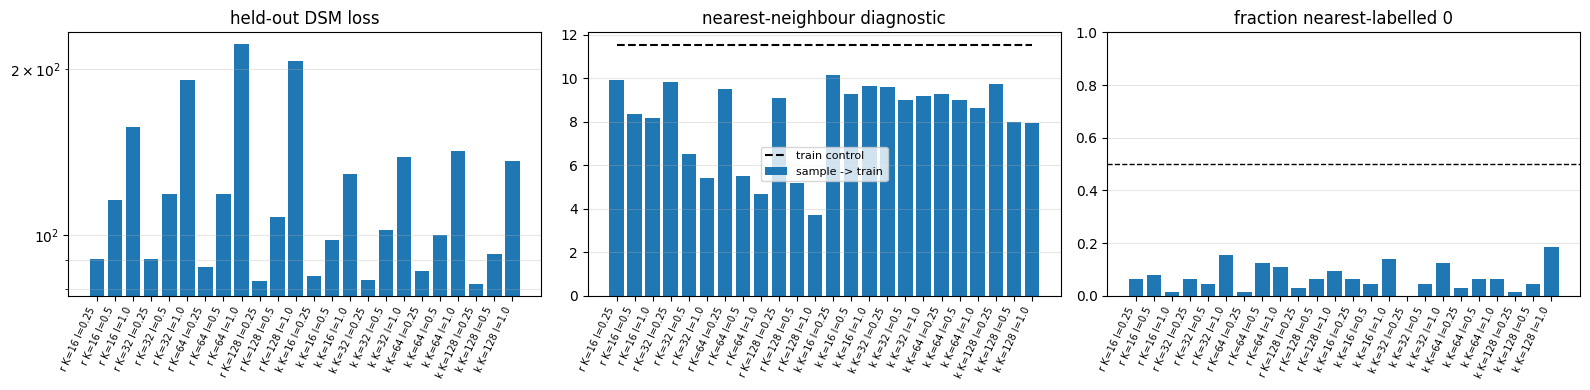

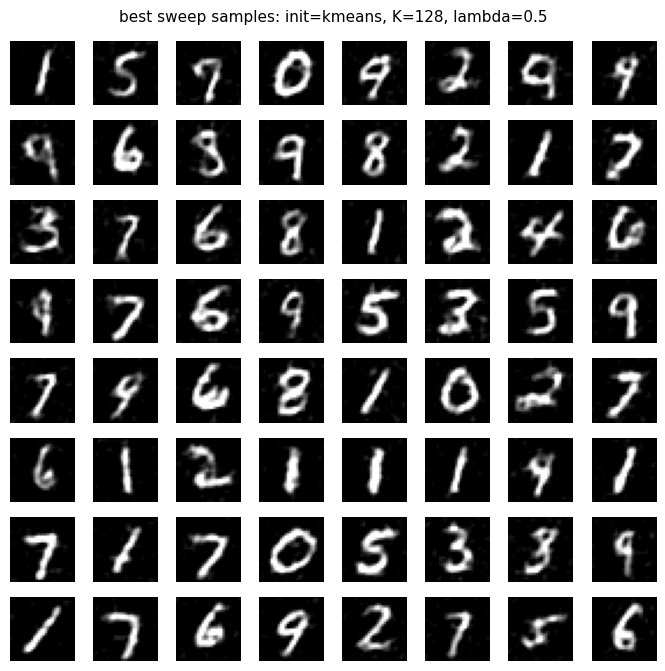

In [13]:
labels = [f"{r['init'][0]} K={r['K']} l={r['lambda']}" for r in sweep_results]
xs = np.arange(len(sweep_results))
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.0))
axes[0].bar(xs, [r["val_loss"] for r in sweep_results])
axes[0].set_yscale("log")
axes[0].set_title("held-out DSM loss")
axes[0].set_xticks(xs)
axes[0].set_xticklabels(labels, rotation=65, ha="right", fontsize=7)
axes[0].grid(alpha=0.3, axis="y", which="both")

axes[1].bar(xs, [r["median_sample_to_train"] for r in sweep_results], label="sample -> train")
axes[1].plot(xs, [r["median_train_to_train"] for r in sweep_results], "k--", label="train control")
axes[1].set_title("nearest-neighbour diagnostic")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(labels, rotation=65, ha="right", fontsize=7)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(xs, [r["zero_frac"] for r in sweep_results])
axes[2].axhline(0.5, color="k", linestyle="--", linewidth=1)
axes[2].set_ylim(0, 1)
axes[2].set_title("fraction nearest-labelled 0")
axes[2].set_xticks(xs)
axes[2].set_xticklabels(labels, rotation=65, ha="right", fontsize=7)
axes[2].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

show_image_grid(best["samples"], f"best sweep samples: init={best['init']}, K={best['K']}, lambda={best['lambda']}")

## Final Retrain

Retrain the selected configuration with a longer schedule and resample.

In [14]:
final_init = best["init"]
final_K = int(best["K"])
final_lambda = float(best["lambda"])
print(f"final config: init={final_init}, K={final_K}, lambda={final_lambda}")

key, sub = random.split(key)
final_params_seq, final_losses, final_wall, key = train_hybrid_schedule(
    sub, train_images, final_K, final_lambda, final_init, TIME_GRID_FINAL,
    steps_per_time=STEPS_PER_TIME_FINAL, batch_size=BATCH_SIZE, verbose=True,
)
final_stacked = stack_hybrid_params(final_params_seq)
key, sub = random.split(key)
final_val = validation_dsm_loss(final_stacked, sub, valid_images, TIME_GRID_FINAL, min(128, BATCH_SIZE), final_lambda)
key, sub = random.split(key)
final_samples, key = reverse_sample_hybrid(sub, final_stacked, TIME_GRID_FINAL, final_lambda, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS)
final_diag = sample_diagnostics(final_samples, train_images, train_labels, prototypes_flat=np.asarray(final_params_seq[0]["dense"]["c"]))
final_summary = summarize_diag(final_diag)

print(f"final wall time: {final_wall:.1f}s")
print(f"final held-out DSM loss: {float(final_val):.4e}")
print("final diagnostics:", final_summary)

final config: init=kmeans, K=128, lambda=0.5


K=128 lambda=0.50 kmeans | t=3.000 sigma2=0.9975 loss=2.8626e-01
K=128 lambda=0.50 kmeans | t=2.735 sigma2=0.9958 loss=4.6879e-01
K=128 lambda=0.50 kmeans | t=2.469 sigma2=0.9928 loss=7.8051e-01
K=128 lambda=0.50 kmeans | t=2.204 sigma2=0.9878 loss=1.2863e+00
K=128 lambda=0.50 kmeans | t=1.938 sigma2=0.9793 loss=2.0925e+00
K=128 lambda=0.50 kmeans | t=1.673 sigma2=0.9648 loss=3.4317e+00
K=128 lambda=0.50 kmeans | t=1.407 sigma2=0.9401 loss=5.5222e+00
K=128 lambda=0.50 kmeans | t=1.142 sigma2=0.8981 loss=8.8541e+00
K=128 lambda=0.50 kmeans | t=0.876 sigma2=0.8267 loss=1.6270e+01
K=128 lambda=0.50 kmeans | t=0.611 sigma2=0.7053 loss=2.6799e+01
K=128 lambda=0.50 kmeans | t=0.345 sigma2=0.4989 loss=6.1062e+01
K=128 lambda=0.50 kmeans | t=0.080 sigma2=0.1479 loss=3.5317e+02
final wall time: 13.7s
final held-out DSM loss: 4.0163e+01
final diagnostics: {'median_sample_to_train': 12.010791778564453, 'median_train_to_train': 11.523661613464355, 'digit_counts': {0: 4, 1: 22, 2: 4, 3: 6, 4: 5, 5:

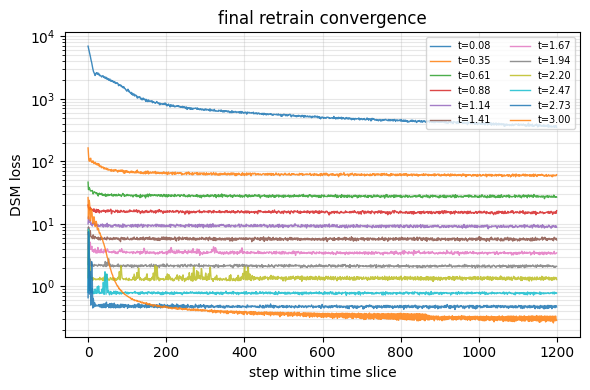

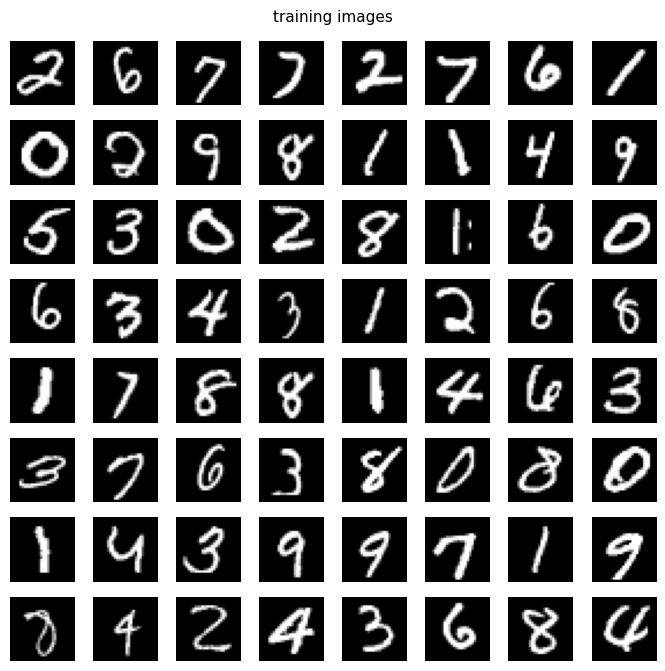

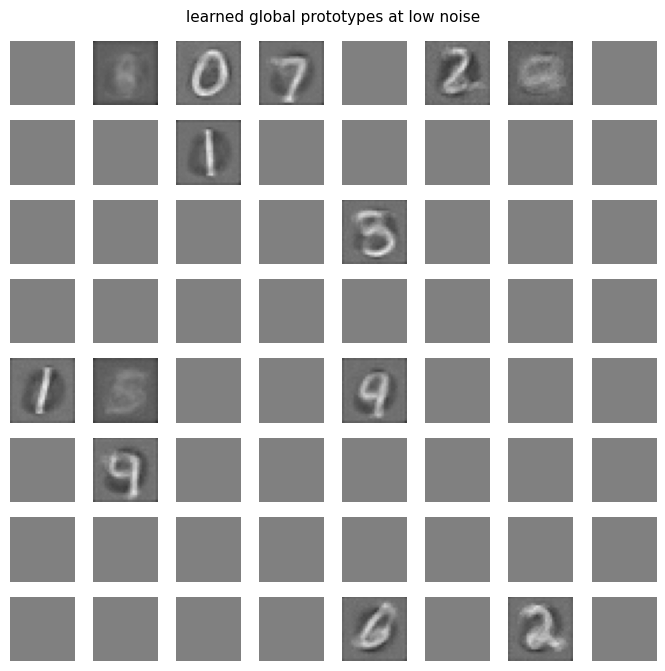

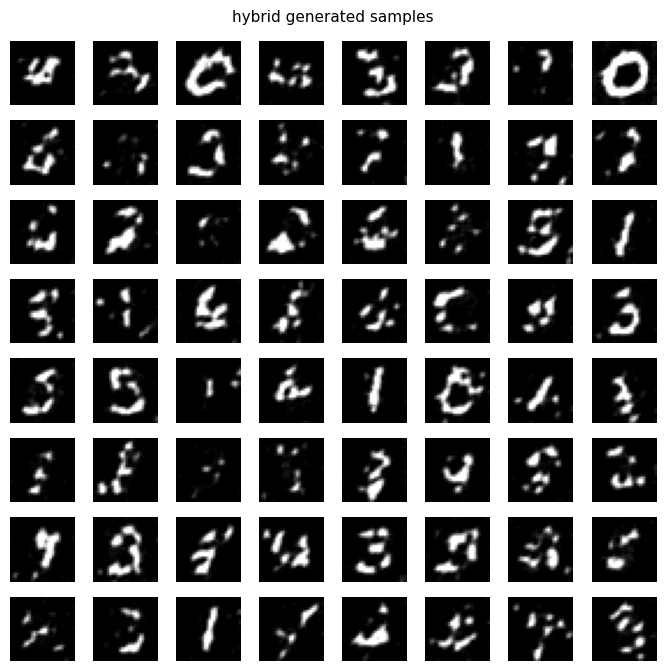

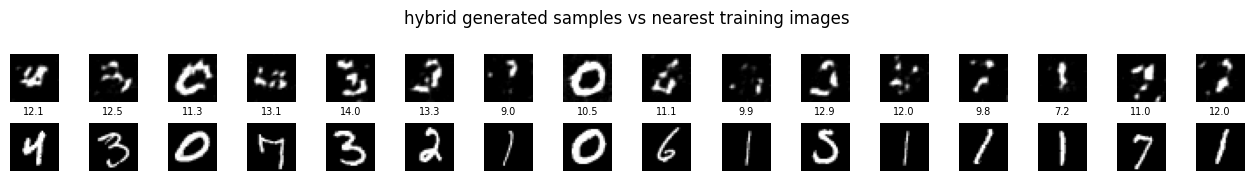

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.0))
for idx, losses in enumerate(final_losses):
    ax.plot(losses, alpha=0.85, linewidth=1.0, label=f"t={float(TIME_GRID_FINAL[idx]):.2f}")
ax.set_yscale("log")
ax.set_xlabel("step within time slice")
ax.set_ylabel("DSM loss")
ax.set_title("final retrain convergence")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

key, k_view = random.split(key)
idx = random.randint(k_view, (N_SAMPLES,), minval=0, maxval=train_images.shape[0])
show_image_grid(train_images[idx], "training images")
protos = np.asarray(final_params_seq[0]["dense"]["c"]).reshape((-1, IMG_SIDE, IMG_SIDE, 1))
show_image_grid(protos, "learned global prototypes at low noise", n_show=min(64, protos.shape[0]))
show_image_grid(final_samples, "hybrid generated samples")

n_pairs = min(16, N_SAMPLES)
fig, axes = plt.subplots(2, n_pairs, figsize=(0.8 * n_pairs, 1.8))
for i in range(n_pairs):
    axes[0, i].imshow(np.asarray(final_samples[i, :, :, 0]), cmap="gray", vmin=-1, vmax=1)
    axes[0, i].axis("off")
    nn_img = np.asarray(train_images[final_diag["nearest_train_idx"][i], :, :, 0])
    axes[1, i].imshow(nn_img, cmap="gray", vmin=-1, vmax=1)
    axes[1, i].set_title(f"{final_diag['d_sample_train'][i]:.1f}", fontsize=7)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("sample", rotation=0, ha="right", va="center")
axes[1, 0].set_ylabel("nearest", rotation=0, ha="right", va="center")
plt.suptitle("hybrid generated samples vs nearest training images")
plt.tight_layout()
plt.show()

## Reading The Result

If the hybrid works, `median_sample_to_train` should move much closer to the train-to-train control than in the pure conv run, and the generated images should look like complete zeros or ones rather than stroke fragments. A very small sample-to-prototype distance means the model is acting like a prototype retriever; a gap between sample-to-train and sample-to-prototype means the conv layer is adding local variation around the global basin.